# Statistical Analysis of the GoFast Scooter Rental Service

We have data about certain users of the GoFast scooter rental service.

Our goal is to analyze the data and test a few hypotheses to help the business grow.

We know that users access the GoFast service through a mobile app to make trips around the city. The service can be used:

Without a subscription:
- No monthly fee;
- The cost per minute is 8 RUB;
- Trip start fee is 50 RUB;

With an Ultra subscription:
- Monthly fee is 199 RUB;
- The cost per minute is 6 RUB;
- No trip start fee.

# Research Goal

To explore the potential for increasing the number of subscription users through promotions, we need to analyze the data across several key areas:

1. Determine whether subscribed users spend more time on their trips.  
2. Check whether the average trip distance for subscribers stays within the optimal range to avoid excessive scooter wear and tear.  
3. Assess whether the monthly revenue from subscribed users exceeds that of non-subscribed users.

Additionally, to evaluate the impact of a recent server upgrade, we’ll conduct a statistical test—such as a t-test—to see whether support requests have decreased after the update.

Our research will follow these main stages:

1. Opening and reviewing the files  
2. Data preprocessing  
3. Performing necessary calculations and adding new columns where needed  
4. Statistical data analysis  
5. Final conclusions

In [1]:
# First, let's load all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import factorial
from scipy import stats as st
pd.set_option('display.max_columns', 30)

### Loading the Data

In [2]:
try:
    user = pd.read_csv('/datasets/users_go.csv')
except:
    user = pd.read_csv('/Users/mariyakostikova/Desktop/Data analyst/Статистика/Project/users_go.csv')
try:
    ride = pd.read_csv('/datasets/rides_go.csv')
except:
    ride = pd.read_csv('/Users/mariyakostikova/Desktop/Data analyst/Статистика/Project/rides_go.csv')
try:
    subs = pd.read_csv('/datasets/subscriptions_go.csv')
except:
    subs = pd.read_csv('/Users/mariyakostikova/Desktop/Data analyst/Статистика/Project/subscriptions_go.csv')

Let’s display the first few rows of each table with descriptions.

**DataFrame: "Users"**

user_id: unique user identifier

name: user's name

age: age

city: city

subscription_type: subscription type (free, ultra)

In [3]:
user.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
# Let's display basic information about the DataFrame.
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


The **ride DataFrame** contains the following columns:

user_id: A unique identifier for the user.

distance: The distance traveled by the user in the current session (in meters).

duration: The duration of the session (in minutes), measured from when the user pressed the "Start ride" button until they pressed the "End ride" button.

date: The date of the ride.

In [5]:
ride.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [6]:
ride.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


The **Subs DataFram**  contains the following columns:

subscription_type: The type of subscription.

minute_price: The cost per minute of the ride for this subscription.

start_ride_price: The cost to start the ride.

subscription_fee: The monthly subscription fee.

In [7]:
subs.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [8]:
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


**Output:**

There are no missing values in the data, which is great.

However, I noticed that the distance column in the "Ride" DataFrame is hard to read. It would be better to round the values to two decimal places.

Also, the date column in "Ride" is of type object. We will need to convert it to a date type.

We will address these issues in the next step.

### Data Preprocessing

#### Data Preprocessing for the "User" 

In [9]:
# Let's take a look at all the data, including their mean, maximum, etc.
user.describe()

,user_id,age
count,1565.000000,1565.000000
mean,762.633866,24.922045
std,443.260155,4.553496
min,1.000000,12.000000
25%,378.000000,22.000000
50%,762.000000,25.000000
75%,1146.000000,28.000000
max,1534.000000,43.000000


In [10]:
# Let's check for duplicates.
user.duplicated().sum()

31

In [11]:
# Delete duplicates
user = user.drop_duplicates()
user.duplicated().sum()

0

In [12]:
# **Let's check the number of unique cities and display them on the screen.**
print(len(user['city'].unique()))
print(user['city'].value_counts())

8
city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64


In [13]:
print(user['city'].nunique())

8


We have removed the duplicates to make the data cleaner.  
There are no missing values, and all the names follow the correct rules.

Surprisingly, Moscow is at the bottom of the scooter rental list, with Pyatigorsk at the top.

#### Data Preprocessing for the "Ride" DataFrame

In [14]:
ride.describe()

,user_id,distance,duration
count,18068.000000,18068.000000,18068.000000
mean,842.869936,3070.659976,17.805011
std,434.734317,1116.831209,6.091051
min,1.000000,0.855683,0.500000
25%,487.000000,2543.226360,13.597563
50%,889.000000,3133.609994,17.678395
75%,1213.250000,3776.222735,21.724800
max,1534.000000,7211.007745,40.823963


In [15]:
# Let's check for duplicates.
ride.duplicated().sum()

0

In [16]:
# Let's convert the `date` column to the pandas `datetime` type
ride.date = pd.to_datetime(ride.date, format='%Y-%m-%d')

In [17]:
# Let's create a new column with the month number based on the date column.
ride['month'] = pd.DatetimeIndex(ride['date']).month

In [18]:
# Let's round the distance and duration columns to two decimal places.
ride['distance'] = ride['distance'].round(2)
ride['duration'] = ride['duration'].round(2)

In [19]:
#Check
ride.info()
ride.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
 4   month     18068 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1)
memory usage: 635.3 KB


,user_id,distance,duration,date,month
0,1,4409.92,25.60,2021-01-01,1
1,1,2617.59,15.82,2021-01-18,1
2,1,754.16,6.23,2021-04-20,4
3,1,2694.78,18.51,2021-08-11,8
4,1,4028.69,26.27,2021-08-28,8


We have added a new column with the month number, changed the data type of the `date` column, and rounded the `distance` and `duration` values to two decimal places.

#### Data Preprocessing for the "Subs" 

In [20]:
subs.describe()

,minute_price,start_ride_price,subscription_fee
count,2.000000,2.000000,2.000000
mean,7.000000,25.000000,99.500000
std,1.414214,35.355339,140.714249
min,6.000000,0.000000,0.000000
25%,6.500000,12.500000,49.750000
50%,7.000000,25.000000,99.500000
75%,7.500000,37.500000,149.250000
max,8.000000,50.000000,199.000000


In [21]:
# Let's check for duplicates 
subs.duplicated().sum()

0

In [22]:
# Let's check how many records we have for each subscription type
user['subscription_type'].value_counts()

subscription_type
free     835
ultra    699
Name: count, dtype: int64

The table contains only 2 rows, with no missing values and no duplicates.

**Conclusion**

After data preprocessing, several steps were completed:

- Duplicates were removed.

- The "date" column in the ride data was converted to the date type.

- A new column was added with the month number of the ride.

- Data analysis was performed, including maximum, minimum values, and other characteristics.

The results of the preprocessing show that the number of users without subscriptions exceeds the number of users with subscriptions, indicating potential for attracting users to the Ultra subscription.

Additionally, there is higher demand for rentals in Pyatigorsk compared to Moscow.

The next step will be to describe and visualize the overall information about users and rides.

### Exploratory Data Analysis

#### City Frequency Distribution

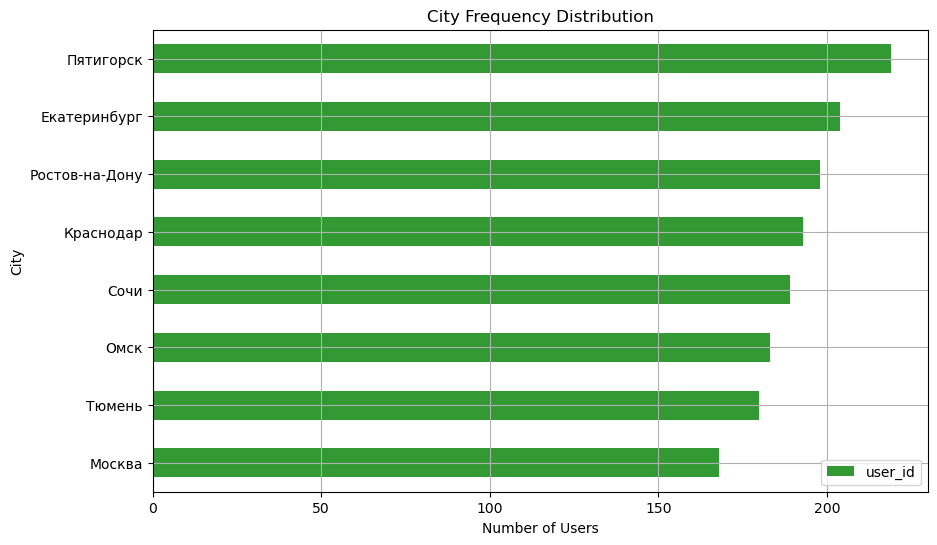

,user_id
city,
Пятигорск,219
Екатеринбург,204
Ростов-на-Дону,198
Краснодар,193
Сочи,189
Омск,183
Тюмень,180
Москва,168


In [23]:
# Number of Users in Each City
user_city = user.pivot_table(index='city', values=['user_id'], aggfunc='count').sort_values(by = 'user_id', ascending = True)
user_city.plot(kind='barh', figsize = (10,6), grid = True, color='green', alpha=0.8)
plt.title('City Frequency Distribution')
plt.xlabel('Number of Users')
plt.ylabel('City')
plt.show()
user_city.sort_values(by = 'user_id', ascending = False)

The data shows that Pyatigorsk has the highest number of users, followed by Yekaterinburg, with Moscow in third place. This is an interesting observation that could be key to developing a user acquisition strategy and optimizing the service in these cities.

##### Ratio of Users with Subscription to Users without Subscription

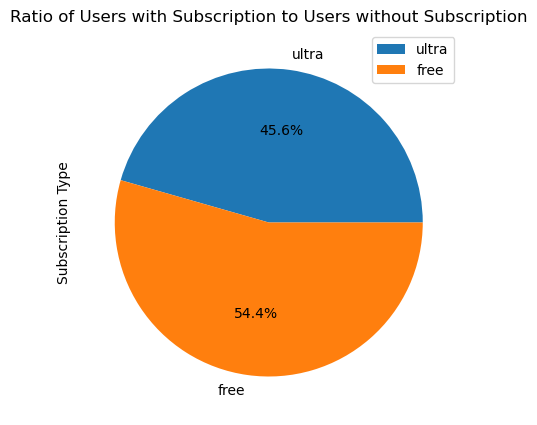

In [24]:
# Breakdown of the Number of Users in Each City

user_subs = user.pivot_table(index='subscription_type', values=['user_id'], aggfunc='count').sort_values(by = 'user_id', ascending = True)
user_subs.plot(kind='pie', figsize=(15, 5), subplots=True, autopct='%1.1f%%')
plt.title('Ratio of Users with Subscription to Users without Subscription')
plt.ylabel('Subscription Type')
plt.show()

The number of users without a subscription is almost 10% higher than the number of users with an Ultra subscription.

##### Возраст пользователей

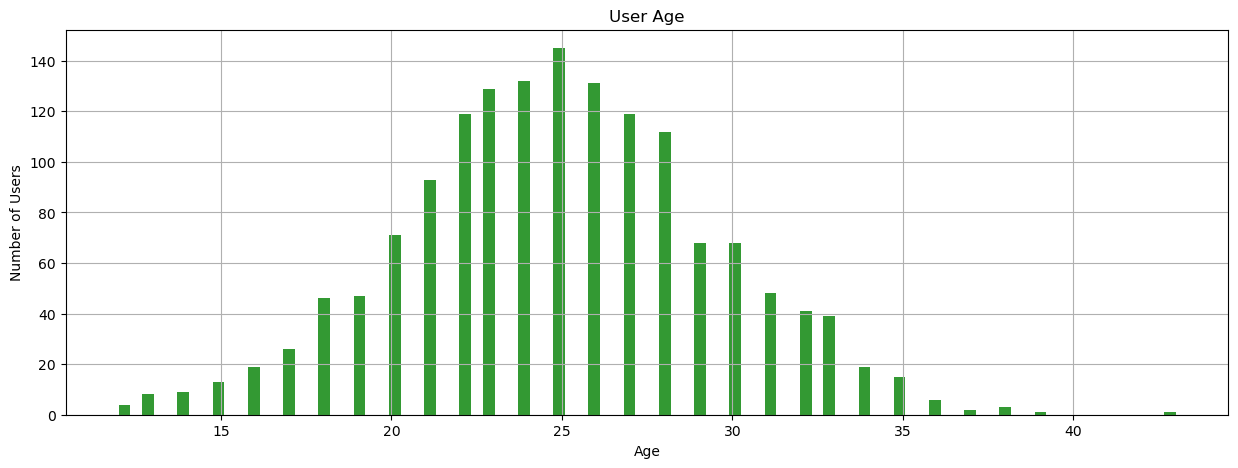

age
25    145
24    132
26    131
23    129
22    119
27    119
28    112
21     93
20     71
30     68
29     68
31     48
19     47
18     46
32     41
33     39
17     26
16     19
34     19
35     15
15     13
14      9
13      8
36      6
12      4
38      3
37      2
39      1
43      1
Name: count, dtype: int64


In [25]:
user['age'].plot(kind='hist', bins=90, figsize = (15,5), grid = True, color='green', alpha=0.8)
plt.title('User Age')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.show()
print(user['age'].value_counts())

In [26]:
user['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

The coincidence of the median and average age indicates that the data is generally balanced and does not contain significant outliers or distortions.

Furthermore, it is observed that the majority of users are in the age group of 22 to 28 years, with their percentage totaling 57.8%. This is an important observation that could help in creating a more targeted marketing strategy or improving the service for this audience.

#### Distance traveled by the user in a single ride

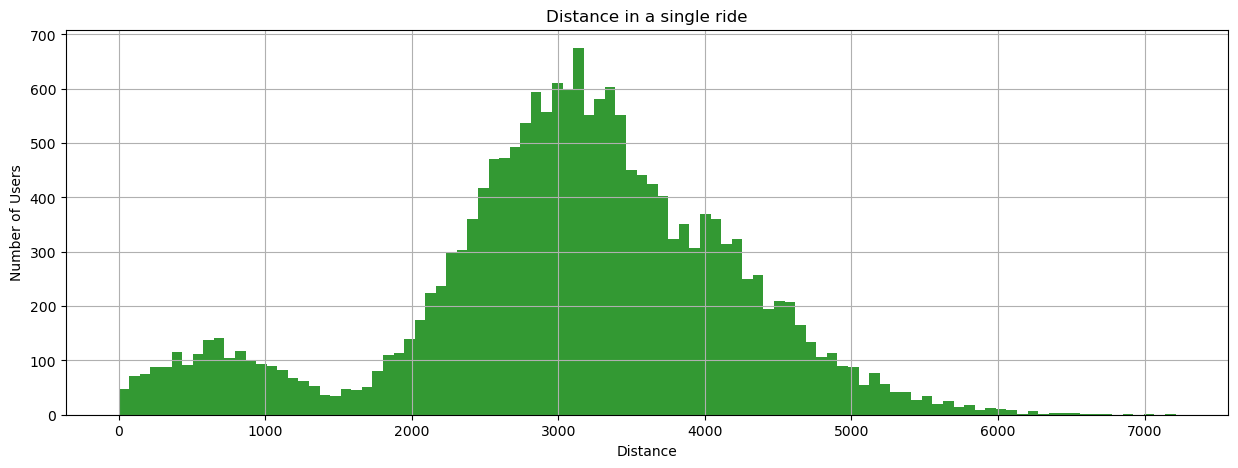

count    18068.000000
mean      3070.659992
std       1116.831222
min          0.860000
25%       2543.227500
50%       3133.610000
75%       3776.220000
max       7211.010000
Name: distance, dtype: float64

In [27]:
ride['distance'].plot(kind='hist', bins=100, figsize = (15,5), grid = True, color='green', alpha=0.8)
plt.title('Distance in a single ride')
plt.xlabel('Distance')
plt.ylabel('Number of Users')
plt.show()
ride['distance'].describe()

The close proximity of the mean and median values indicates a lack of significant dispersion in the data.

It is noted that there are users who completed a ride of about 1 meter. This could be related to various factors, such as a weak scooter battery or a change of plans by the user.

It is also observed that some users traveled up to 7,000 meters. This may be due to long trips to the nearest metro, university, or work, or being caught in traffic.

#### Ride Duration


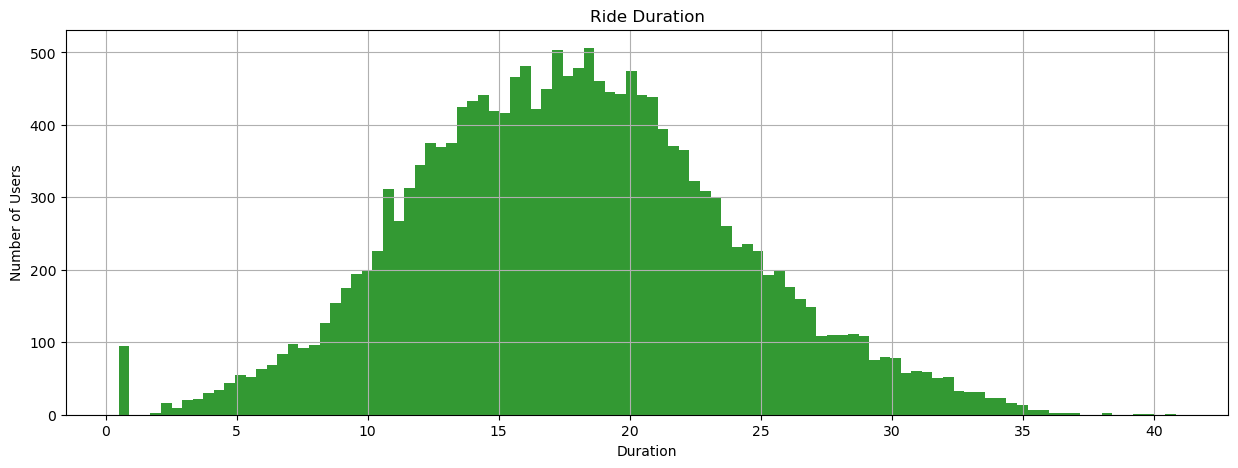

count    18068.000000
mean        17.805017
std          6.091071
min          0.500000
25%         13.600000
50%         17.680000
75%         21.722500
max         40.820000
Name: duration, dtype: float64

In [28]:
ride['duration'].plot(kind='hist', bins=100, figsize = (15,5), grid = True, color='green', alpha=0.8)
plt.title('Ride Duration')
plt.xlabel('Duration')
plt.ylabel('Number of Users')
plt.show()
ride['duration'].describe()

<Axes: xlabel='duration', ylabel='distance'>

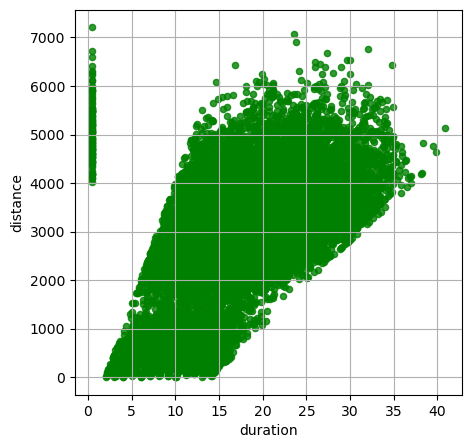

In [29]:
ride.plot(x='duration',
         y='distance',
         grid=True,
         kind='scatter',
         alpha=0.8,
         figsize = (5,5),
         color='green')

The absence of significant dispersion in the data is confirmed, as the mean and median values are almost identical.

It is noted that some users completed rides in less than a minute, which likely corresponds to cases where the ride distance was very small, less than 1 meter.

On average, users use the scooter for about 17 minutes. This is useful information that can help optimize the service and improve the user experience.

**Conclusio**

The coincidence of the median and average values indicates the balance of the data and the absence of significant outliers.

Pyatigorsk leads in the number of users, followed by Yekaterinburg, with Moscow at the bottom. This provides valuable insights for developing strategies to attract users and improve the service in these cities.

The majority of users fall within the age group of 22 to 28 years, which constitutes 57.8% of the total. This is an important observation for shaping a targeted marketing strategy and improving the service for this audience. Additionally, the number of users without a subscription exceeds the number of users with an Ultra subscription by almost 10%.

There is a wide range in the duration of rides, from extremely short to long trips, which may be due to various factors, such as technical issues or long-distance trips.

The average time spent using the scooter is about 17 minutes. This information can be useful for optimizing the service and improving the user experience.

These findings provide valuable insights for further analysis and the development of strategies to improve the service and attract new users.

### Data Merging

#### Merging Data on Users, Rides, and Subscriptions

In [30]:
# Merging user, ride data on "user_id"
data_union = pd.merge(user, ride, on='user_id', how='inner')

# Then merging with sub on "user_id"
data_union = pd.merge(data_union, subs, on='subscription_type', how='inner')

data_union.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.92,25.60,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.59,15.82,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.16,6.23,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.78,18.51,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.69,26.27,2021-08-28,8,6,0,199


In [31]:
data_union.isnull().sum()
# no Null

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

#### Let's create two separate dataframes from the dataframe created in step 4.1
- one for users without subscriptions
- one for users with subscriptions

In [32]:
#  without subscriptions
data_union_free = data_union[data_union['subscription_type'] == 'free']
#  reset the index
data_union_free.reset_index(drop=True, inplace=True)
data_union_free.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,700,Айдар,22,Омск,free,2515.69,14.94,2021-01-02,1,8,50,0
1,700,Айдар,22,Омск,free,846.93,16.23,2021-02-01,2,8,50,0
2,700,Айдар,22,Омск,free,4004.43,20.02,2021-02-04,2,8,50,0
3,700,Айдар,22,Омск,free,1205.91,9.78,2021-02-10,2,8,50,0
4,700,Айдар,22,Омск,free,3047.38,17.43,2021-02-14,2,8,50,0


In [33]:
data_union_free.describe().round(2)

,user_id,age,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
count,11568.00,11568.00,11568.00,11568.00,11568,11568.00,11568.0,11568.0,11568.0
mean,1120.53,24.89,3045.50,17.39,2021-07-01 21:47:03.236514560,6.52,8.0,50.0,0.0
min,700.00,12.00,0.86,0.50,2021-01-01 00:00:00,1.00,8.0,50.0,0.0
25%,915.00,22.00,2366.56,12.96,2021-04-02 00:00:00,4.00,8.0,50.0,0.0
50%,1123.00,25.00,3114.65,17.33,2021-07-01 00:00:00,7.00,8.0,50.0,0.0
75%,1328.00,28.00,3905.70,21.59,2021-09-30 00:00:00,9.00,8.0,50.0,0.0
max,1534.00,43.00,7211.01,34.95,2021-12-30 00:00:00,12.00,8.0,50.0,0.0
std,241.17,4.48,1246.17,6.33,NaN,3.45,0.0,0.0,0.0


In [34]:
# with subscriptions
data_union_ultra = data_union[data_union['subscription_type'] == 'ultra']
# reset the index
data_union_ultra.reset_index(drop=True, inplace=True)
data_union_ultra.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.92,25.60,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.59,15.82,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.16,6.23,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.78,18.51,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.69,26.27,2021-08-28,8,6,0,199


In [35]:
data_union_ultra.describe().round(2)

,user_id,age,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
count,6500.00,6500.00,6500.00,6500.00,6500,6500.00,6500.0,6500.0,6500.0
mean,348.73,24.89,3115.45,18.54,2021-06-28 21:31:34.153846016,6.42,6.0,0.0,199.0
min,1.00,12.00,244.21,3.76,2021-01-01 00:00:00,1.00,6.0,0.0,199.0
25%,175.00,22.00,2785.45,14.53,2021-04-01 00:00:00,4.00,6.0,0.0,199.0
50%,351.00,25.00,3148.64,18.18,2021-06-27 00:00:00,6.00,6.0,0.0,199.0
75%,525.00,28.00,3560.58,21.88,2021-09-25 00:00:00,9.00,6.0,0.0,199.0
max,699.00,38.00,5699.77,40.82,2021-12-30 00:00:00,12.00,6.0,0.0,199.0
std,201.10,4.76,836.90,5.57,NaN,3.41,0.0,0.0,0.0


#### Visualize the information about the distance and duration of rides for users of both categories.

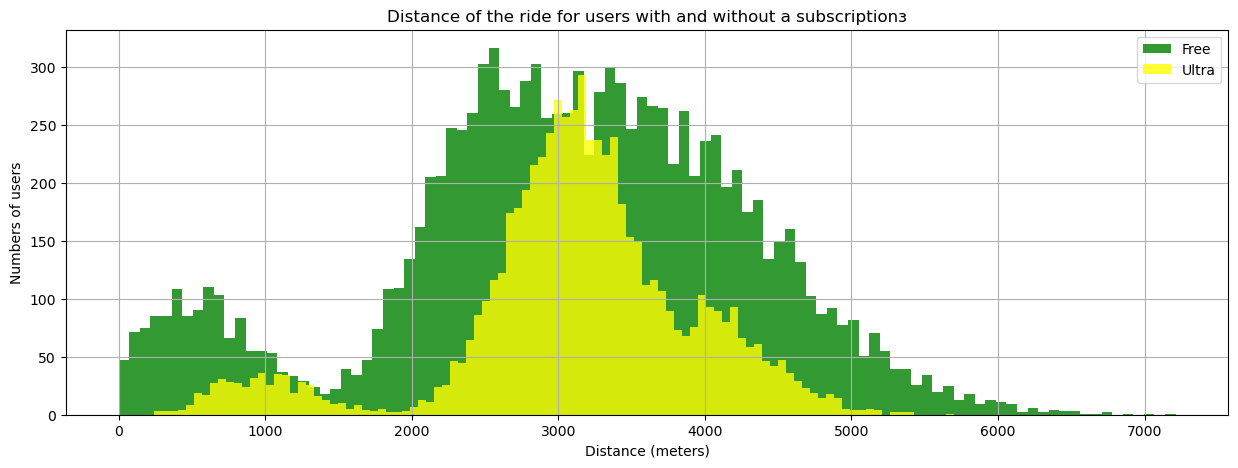

In [36]:
# Visualize the information about the distance and duration of rides for users of both categories.
distance = data_union_free['distance'].plot(kind='hist', bins=100, figsize = (15,5), grid = True, color='green', alpha=0.8, label='Free')
distance = data_union_ultra['distance'].plot(kind='hist', bins=100, figsize = (15,5), grid = True, color='yellow', alpha=0.8, label='Ultra')
plt.title('Distance of the ride for users with and without a subscriptionз')
plt.xlabel('Distance (meters)')
plt.ylabel('Numbers of users')
plt.legend(loc='upper right')
plt.show()

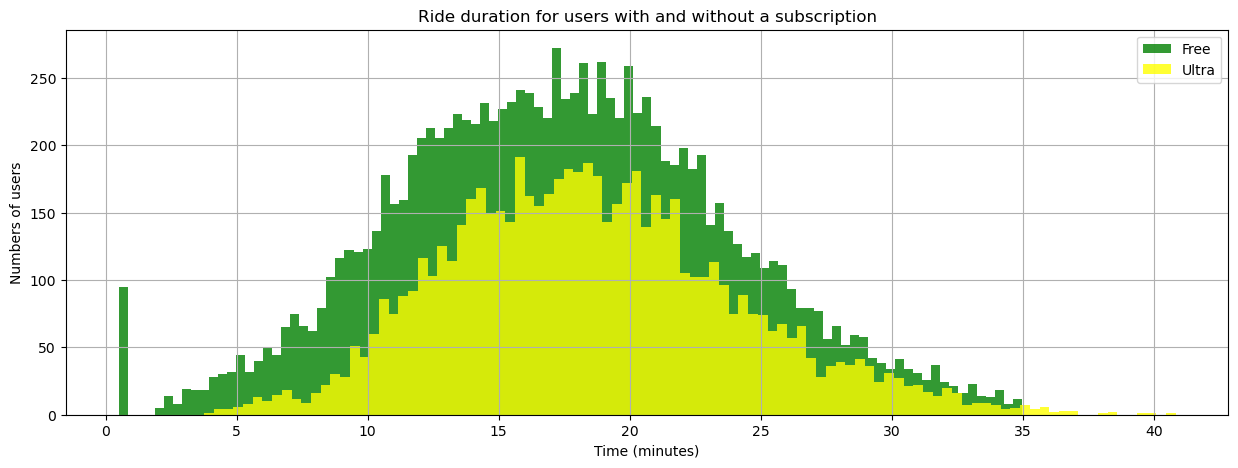

In [37]:
# Visualize ride duration  
distance = data_union_free['duration'].plot(kind='hist', bins=100, figsize = (15,5), grid = True, color='green', alpha=0.8, label='Free')
distance = data_union_ultra['duration'].plot(kind='hist', bins=100, figsize = (15,5), grid = True, color='yellow', alpha=0.8, label='Ultra')
plt.title('Ride duration for users with and without a subscription')
plt.xlabel('Time (minutes)')
plt.ylabel('Numbers of users')
plt.legend(loc='upper right')
plt.show()

**Conclusion**

es, the differences in the distances between users with an Ultra subscription and those without a subscription clearly reflect different usage patterns of the service.

For users with an Ultra subscription, the minimum distance is about 240 meters, suggesting that they likely take longer rides compared to users without a subscription. The maximum distance of 6000 meters also supports this trend.

Meanwhile, for users without a subscription, there is a significant variation in the distances, ranging from less than 1 meter to 7000 meters. This could be due to various factors such as occasional short-distance rides or long commutes, as you noted.

Interestingly, despite these differences in distances, the average values for both groups are similar. This may suggest that the overall usage patterns are similar for both groups, despite the differences in the minimum and maximum distance values.

As for the ride durations, users without a subscription show a wide variation in ride times, ranging from less than a second to 35 minutes. This might indicate random or short trips, possibly without much planning.

On the other hand, users with a subscription show more stable ride durations, with a minimum of 4 minutes and a maximum of 41 minutes. This could suggest more systematic usage of the subscription, possibly for longer trips or commuting.

The graph shows differences in the distribution of ride times for both groups. For users without a subscription, there are peaks around 1 minute and 17 minutes, whereas for users with an Ultra subscription, the distribution is more even, with a possible peak around 16 minutes.

These observations can help better understand the usage patterns and tailor strategies for attracting and retaining users.

### Revenue Calculation

#### Total distance, number of rides, and total duration for each user per month.

In [38]:
#Round the trip duration.
data_union['duration'] = np.ceil(data_union['duration'])
data_union['duration'] = data_union['duration'].astype('int')

In [39]:
data_grouped = (data_union.groupby(['user_id', 'month'])
                   .agg({'distance':'sum'
                          , 'duration':['sum', 'count']
                          , 'subscription_type':'first'
                          , 'minute_price':'first'
                          , 'start_ride_price':'first'
                          , 'subscription_fee':'first'})
                   .reset_index())
data_grouped.head()

user_id month distance duration       subscription_type minute_price  \
                     sum      sum count             first        first   
0       1     1  7027.51       42     2             ultra            6   
1       1     4   754.16        7     1             ultra            6   
2       1     8  6723.47       46     2             ultra            6   
3       1    10  5809.91       32     2             ultra            6   
4       1    11  7003.50       56     3             ultra            6   

  start_ride_price subscription_fee  
             first            first  
0                0              199  
1                0              199  
2                0              199  
3                0              199  
4                0              199

In [40]:
data_grouped.columns=['user_id', 'month', 'sum_distance','sum_duration', 'count_rides', 'subscription_type', 'minute_price',
                     'start_ride_price', 'subscription_fee']
data_grouped.head()

,user_id,month,sum_distance,sum_duration,count_rides,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,7027.51,42,2,ultra,6,0,199
1,1,4,754.16,7,1,ultra,6,0,199
2,1,8,6723.47,46,2,ultra,6,0,199
3,1,10,5809.91,32,2,ultra,6,0,199
4,1,11,7003.50,56,3,ultra,6,0,199


#### Adding a column with the monthly revenue generated by each user.

In [41]:
# Now let's calculate the revenue for each month.
data_grouped['monthly_revenue'] = data_grouped['start_ride_price'] * data_grouped['count_rides']  + data_grouped['minute_price'] * data_grouped['sum_duration'] + data_grouped['subscription_fee']
data_grouped.head()

,user_id,month,sum_distance,sum_duration,count_rides,subscription_type,minute_price,start_ride_price,subscription_fee,monthly_revenue
0,1,1,7027.51,42,2,ultra,6,0,199,451
1,1,4,754.16,7,1,ultra,6,0,199,241
2,1,8,6723.47,46,2,ultra,6,0,199,475
3,1,10,5809.91,32,2,ultra,6,0,199,391
4,1,11,7003.50,56,3,ultra,6,0,199,535


### Hypothesis Testing

#### Do users with subscriptions spend more time on rides?

It is important to understand whether users with subscriptions spend more time on rides. If they do, users with subscriptions could be more "valuable" to the company. Let's test this hypothesis. Use the original data on the duration of each session — separately for subscribers and non-subscribers.

We will compare the two samples, data_union_free and data_union_ultra, and test the following theories:

- Null hypothesis H₀: Users with or without subscriptions spend the same amount of time on rides.

- Alternative hypothesis H₁: Users with subscriptions spend more time on rides.

In [42]:
# Level of Statistical Significance
alpha = 0.05 

results = st.ttest_ind(data_union_ultra['duration'], data_union_free['duration'], alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Do not reject the null hypothesis')

p-value: 1.274138957151199e-34
Reject the null hypothesis


The hypothesis is true: the average ride time for users with Ultra subscriptions is longer than the average ride time for users without subscriptions.

In [43]:
# Let's display the average for both groups:
print('The average ride time for users with an Ultra subscription is', data_union_ultra['duration'].mean().round(2))
print('The average ride time for users without a subscription is',data_union_free['duration'].mean().round(2))

The average ride time for users with an Ultra subscription is 18.54
The average ride time for users without a subscription is 17.39


Calculations are correct, we see that users with a subscription spend on average 1.25 minutes more on a ride.

#### Does the average distance traveled by users with a subscription per ride not exceed 3130 meters?

A ride distance of 3130 meters is optimal in terms of scooter wear and tear. Can we say that the average distance traveled by users with a subscription per ride does not exceed 3130 meters?

Let's take only the data_union_ultra sample and test the following hypotheses:

- Null hypothesis H₀: The average distance traveled by users with a subscription is equal to 3130 meters

- Alternative hypothesis H₁: The average distance traveled by users with a subscription is greater than 3130 meters

In [44]:
interested_value = 3130

alpha = 0.05

results = st.ttest_1samp(data_union_ultra['distance'], interested_value, alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Do not reject the null hypothesis')

p-value: 0.9195362605842414
Do not reject the null hypothesis


We could not reject the null hypothesis, which means that users with the Ultra subscription, on average, travel less than 3130 meters.
To be more confident, let's check the average again as we did in section 6.1.

In [45]:
print('The average distance for users with an Ultra subscription is', data_union_ultra['distance'].mean().round(2))

The average distance for users with an Ultra subscription is 3115.45


#### Is the monthly revenue from users with a subscription higher than the revenue from users without a subscription?

To test the hypothesis of whether the monthly revenue from users with a subscription is higher than the revenue from users without a subscription.

We will compare two samples, data_union_free (users without a subscription) and data_union_ultra (users with a subscription), and test the following hypotheses:

- Null hypothesis (H₀): The monthly revenue from users with and without a subscription is the same.

- Alternative hypothesis (H₁): The monthly revenue from users with a subscription is higher than from users without a subscription.

In [46]:
# First, the data should be split into two samples: one with a subscription and one without.
data_grouped_ultra = data_grouped[data_grouped['subscription_type'] == 'ultra']
data_grouped_free = data_grouped[data_grouped['subscription_type'] == 'free']

# The level of statistical significance.
alpha = 0.05 

results = st.ttest_ind(data_grouped_ultra['monthly_revenue'], data_grouped_free['monthly_revenue'], alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Do not reject the null hypothesis')

p-value: 1.8164914860049708e-31
Reject the null hypothesis


The obtained p-value is lower than the specified significance level, so we can reject the null hypothesis that the monthly revenue from users with a subscription does not differ. Therefore, we have grounds to believe that the monthly revenue from users with a subscription is higher than that from users without a subscription.

Let's check again with calculations.

In [47]:
print('The average monthly revenue from ultra subscription users is', data_grouped_ultra['monthly_revenue'].mean().round(2))
print('The average monthly revenue without subscription is', data_grouped_free['monthly_revenue'].mean().round(2))

The average monthly revenue from ultra subscription users is 362.73
The average monthly revenue without subscription is 328.58


**Conclusion**

Based on the conducted analysis, the following conclusions can be made:

1) Users with an Ultra subscription spend, on average, more time on trips than users with a regular subscription.

2) The average distance traveled by Ultra subscription users in a single trip is less than 3130 meters, which may indicate shorter trips compared to users with a regular subscription.

3) The p-value obtained when analyzing the monthly revenue from subscribers was less than the specified significance level. This means that we can reject the null hypothesis that the monthly revenue from subscribers is not different from the revenue from non-subscribers. Therefore, there is reason to believe that the monthly revenue from subscribers exceeds the revenue from non-subscribers.

### General Conclusion

Our research aimed to identify the potential for increasing the number of subscription users through promotions, as well as assess the effectiveness of server upgrades. To achieve this, we conducted an analysis of the data across several key aspects.

The investigation began with opening the files and examining their contents. We then performed data preprocessing, including removing duplicates, converting data types, and adding new columns for easier analysis.

The data analysis led us to the following conclusions:

Firstly, we found that the number of users without subscriptions exceeds the number of users with subscriptions, especially Ultra subscriptions. This indicates potential for attracting new users to paid subscriptions, particularly in regions with high demand, such as Pyatigorsk.

Secondly, the ride analysis showed that Ultra subscription users, on average, spend more time on rides, but their average ride distance is shorter than that of non-subscribed users. This is important for optimizing the service and meeting the needs of different user groups.

The third conclusion concerns revenue. We found that the monthly revenue from subscribed users exceeds the revenue from non-subscribed users. This may indicate the benefits of paid subscriptions for the business.

Additionally, we discovered that Pyatigorsk has the highest number of users, followed by Yekaterinburg, with Moscow at the bottom. This is an interesting observation that could be key to developing a user acquisition strategy and optimizing the service in these cities. The coincidence of the median and mean suggests that the data is generally balanced and free from significant outliers or distortions.

We can also highlight two peaks in the distance data, which indicate the following. The first small peak could be explained by users renting scooters to reach metro stations or other public transport stops. The second, higher peak, might be related to long rides to the nearest metro, university, or work, or could indicate traffic congestion. Additionally, it was observed that the majority of users are in the age group from 22 to 28 years, making up 57.8%. This is an important observation that could help in creating a more targeted marketing strategy or improving the service for this audience. Perhaps the company could create a separate tariff for students who can use scooters to get to university or side jobs.

Finally, to assess the effectiveness of the server upgrades, we can use the appropriate ttest_rel from the scipy.stats library for statistical testing. The results of this analysis could confirm or refute the hypothesis of a decrease in support requests after the upgrade, providing valuable data for the analyst.

Overall, our research provides valuable insights for developing strategies to attract new users, optimize the service, and evaluate the effectiveness of technical changes.